# **Using MRI for Brain Tumor Detection and Segmentation**

**Authors:** Isha Dev, Dharvi Jagirdar, Rohan Giridharan

This notebook contains the code to generate synthetic .nii data utilizing the BraTS 2020 data



## **Set Up and Imports**

In [ ]:
!pip install -q kaggle nibabel tqdm scikit-image

import os
import glob
import time
import numpy as np
import nibabel as nib
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.transform import rotate
from tensorflow.image import ssim_multiscale

In [ ]:
# Create the 'kaggle' directory if it doesn't exist
kaggle_dir = '/content/drive/MyDrive/kaggle'
if not os.path.exists(kaggle_dir):
  os.makedirs(kaggle_dir)

# Install kaggle API
!pip install -q kaggle

# Check for kaggle.json in the kaggle directory
kaggle_json_path = os.path.join(kaggle_dir, 'kaggle.json')
if not os.path.exists(kaggle_json_path):
    # Upload your kaggle.json file
    from google.colab import files
    uploaded = files.upload()
else:
    print("kaggle.json found in kaggle directory. Skipping upload.")

# Move the kaggle.json file to the correct location
!mkdir -p ~/.kaggle
!cp {kaggle_json_path} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Check if dataset already exists
dataset_path = os.path.join(kaggle_dir, 'brats20-dataset-training-validation.zip')
if not os.path.exists(dataset_path):
    # Download the dataset from Kaggle
    !kaggle datasets download -d awsaf49/brats20-dataset-training-validation -p /content/drive/MyDrive/kaggle
    print("Dataset downloaded successfully!")
else:
    print("Dataset already exists. Skipping download.")

# Check if dataset is extracted
extracted_path = os.path.join(kaggle_dir, 'BraTS2020_TrainingData')
if not os.path.exists(extracted_path):
    # Extract the dataset
    !unzip /content/drive/MyDrive/kaggle/brats20-dataset-training-validation.zip -d /content/drive/MyDrive/kaggle
    print("Dataset extracted successfully!")
else:
    print("Dataset already extracted. Skipping extraction.")

print("Dataset ready to use!")

# Training Data:
TRAIN_PATH = os.path.join(
    kaggle_dir,
    'BraTS2020_TrainingData',
    'MICCAI_BraTS2020_TrainingData'
)
print("Found training data at:", TRAIN_PATH)

kaggle.json found in kaggle directory. Skipping upload.
Dataset already exists. Skipping download.
Dataset already extracted. Skipping extraction.
Dataset ready to use!
Found training data at: /content/drive/MyDrive/kaggle/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData


In [ ]:
# XLA JIT + mixed precision + GPU growth
tf.config.optimizer.set_jit(True)
tf.keras.mixed_precision.set_global_policy('mixed_float16')
for g in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(g, True)

print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TF version: 2.18.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## **Hyperparameters and Diffusion Schedule**

In [ ]:
BASE_CH     = 16
TIME_DIM    = 64
EPOCHS      = 30
LR          = 2e-4

T = 200
betas  = np.linspace(1e-4, 2e-2, T, dtype=np.float32)
alphas = 1.0 - betas
acp = np.cumprod(alphas)
sqrt_acp = tf.constant(np.sqrt(acp),     dtype=tf.float32)
sqrt_one_m_acp = tf.constant(np.sqrt(1 - acp), dtype=tf.float32)

In [ ]:
# Load Flair images
all_files = sorted(glob.glob(os.path.join(TRAIN_PATH, '*/BraTS20_*_flair.nii')))
vols = { f: nib.load(f) for f in all_files }

# tf.data pipeline for multimodal volumes
WINDOW_SIZE = 9
BATCH_SUBJS = 4

MODS = ['flair','t1','t1ce','t2','seg']
C = len(MODS)
IMG_SHAPE = (240,240,C)

def _load_and_sample_multimod(fpath):
    # fpath is the FLAIR file; swap flair→others
    base = os.path.dirname(fpath.decode('utf-8'))
    arrays = []
    for m in MODS:
        p = glob.glob(os.path.join(base, f'*_{m}.nii'))[0]
        arr = nib.load(p).get_fdata().astype(np.float32)
        if m=='seg':
            # keep mask as integer classes 0,1,2… then normalize to [–1,1]
            arr = (arr / arr.max())*2 - 1
        else:
            # intensity modals → [–1,1]
            mn, mx = arr.min(), arr.max()
            arr = (arr - mn)/(mx - mn)*2 - 1
        arrays.append(arr)              # shape (240,240,D)
    arrays = np.stack(arrays, axis=-1)  # (240,240,D, C)

    # sample WINDOW_SIZE indices, extract slices, as before
    D = arrays.shape[2]
    idx = np.random.choice(D, size=WINDOW_SIZE, replace=False)
    out = []
    for s in idx:
        out.append(arrays[:,:,s,:])      # (240,240,C)
    return np.stack(out, 0)             # (9, 240,240, C)

# TF Pipeline
def _tf_sample_with_path(fpath):
    out = tf.numpy_function(_load_and_sample_multimod,
                            [fpath],
                            tf.float32)
    out.set_shape((WINDOW_SIZE, IMG_SHAPE[0], IMG_SHAPE[1], C))
    # AND return the path
    return out, fpath

ds = (
    tf.data.Dataset
      .from_tensor_slices(all_files)
      .shuffle(len(all_files))
      .map(_tf_sample_with_path, num_parallel_calls=tf.data.AUTOTUNE)
      .batch(BATCH_SUBJS, drop_remainder=True)
      .prefetch(tf.data.AUTOTUNE)
)

print("Pipeline ready - each element shape:", next(iter(ds))[0].shape)

Pipeline ready – each element shape: (4, 9, 240, 240, 5)


In [ ]:
# Sinusoidal time embeddings
def get_timestep_embedding(t, dim=TIME_DIM):
    half = dim // 2
    freqs = tf.exp(tf.linspace(0., tf.math.log(10000.), half))
    args  = tf.cast(t, tf.float32)[:, None] * freqs[None, :]
    return tf.concat([tf.sin(args), tf.cos(args)], axis=-1)

## Model

In [ ]:
# 2D Unet model
class ConvBlock(layers.Layer):
    def __init__(self, in_ch=C, base_ch=BASE_CH):
        super().__init__()
        ch = base_ch
        self.c  = layers.Conv2D(ch, 3, padding='same', use_bias=False)
        self.gn = layers.GroupNormalization(8)
    def call(self, x):
        return tf.nn.silu(self.gn(self.c(x)))

class DiffusionUNet(Model):
    def __init__(self, in_ch=C, base_ch=BASE_CH):
        super().__init__()
        self.temb = layers.Dense(TIME_DIM, activation='swish')
        # down
        self.c1 = ConvBlock(BASE_CH)
        self.d1 = layers.Conv2D(BASE_CH*2, 4, 2, 'same')
        self.c2 = ConvBlock(BASE_CH*2)
        # bottleneck
        self.mb = ConvBlock(BASE_CH*2)
        # up
        self.u1 = layers.Conv2DTranspose(BASE_CH*2, 4, 2, 'same')
        self.c3 = ConvBlock(BASE_CH*2)
        self.u2 = layers.Conv2DTranspose(BASE_CH,   4, 2, 'same')
        self.c4 = ConvBlock(BASE_CH)
        # out
        self.out = layers.Conv2D(in_ch,1,padding='same')

    def call(self, x, t):
        # time‑embed
        tem = get_timestep_embedding(t)
        tem = self.temb(tem)[:, None, None, :]
        # down
        h1 = self.c1(x)
        d1 = self.d1(h1)
        h2 = self.c2(d1)
        m  = self.mb(h2)
        # up1
        u1 = self.u1(m)
        u1 = tf.image.resize(u1, [h2.shape[1], h2.shape[2]],
                              method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
        u1 = self.c3(tf.concat([u1, h2], axis=-1))
        # up2
        u2 = self.u2(u1)
        u2 = tf.image.resize(u2, [h1.shape[1], h1.shape[2]],
                              method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
        u2 = self.c4(tf.concat([u2, h1], axis=-1))
        return self.out(u2)

In [ ]:
# Optimizer, loss, and updated train_step
model = DiffusionUNet()
opt   = tf.keras.optimizers.Adam(LR)
mse   = tf.keras.losses.MeanSquaredError()

@tf.function
def train_step(window_batch):
    # flatten batch of windows to individual slices
    x = tf.reshape(window_batch, [-1, IMG_SHAPE[0], IMG_SHAPE[1], C])  # clean images in [–1,1], keep all channels (C)
    B = tf.shape(x)[0]
    t = tf.random.uniform([B], 0, T, dtype=tf.int32)
    eps = tf.random.normal(tf.shape(x))

    # compute forward-diffusion
    a = tf.gather(sqrt_acp,       t)[:,None,None,None]
    b = tf.gather(sqrt_one_m_acp, t)[:,None,None,None]

    # Cast a and b to float32
    a = tf.cast(a, tf.float32)
    b = tf.cast(b, tf.float32)

    xt = a * x + b * eps

    with tf.GradientTape() as tape:
        pred_eps = model(xt, t)  # predict noise
        # Cast pred_eps to float32 before calculating loss
        pred_eps = tf.cast(pred_eps, tf.float32)
        loss = mse(eps, pred_eps)
    grads = tape.gradient(loss, model.trainable_variables)
    opt.apply_gradients(zip(grads, model.trainable_variables))

    # reconstruct x0 from the network’s noise prediction
    x0_pred = (xt - b * pred_eps) / a
    x0_pred = tf.clip_by_value(x0_pred, -1.0, 1.0)

    # compute MS-SSIM in [0,1] per image, then average
    ms_ssim_vals = ssim_multiscale(x0_pred, x, max_val=2.0)
    mean_ms_ssim = tf.reduce_mean(ms_ssim_vals)

    return loss, mean_ms_ssim

Epoch 1/30:   0%|          | 0/92 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:774: UserWarning: Gradients do not exist for variables ['diffusion_u_net_7/dense_7/kernel', 'diffusion_u_net_7/dense_7/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
Epoch 1/30:  49%|████▉     | 45/92 [01:52<02:23,  3.06s/it, loss=0.9035, ms-ssim=0.3302]

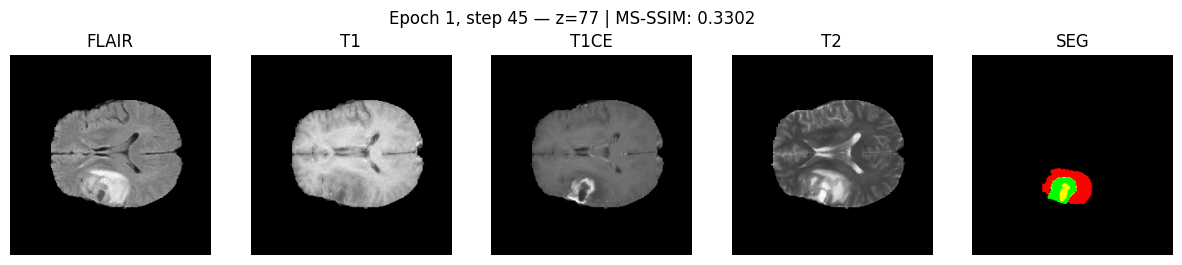

Epoch 1/30:  98%|█████████▊| 90/92 [03:40<00:04,  2.50s/it, loss=0.7155, ms-ssim=0.4272]

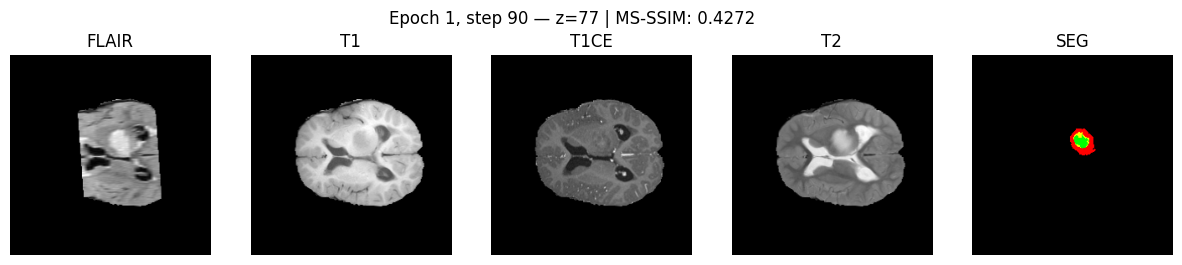

Epoch 1/30: 100%|██████████| 92/92 [03:43<00:00,  2.43s/it, loss=0.7283, ms-ssim=0.4523]


Epoch 01/30  avg loss = 0.95211  avg MS-SSIM = 0.3955


Epoch 2/30:  49%|████▉     | 45/92 [01:27<02:27,  3.14s/it, loss=0.6005, ms-ssim=0.4137]

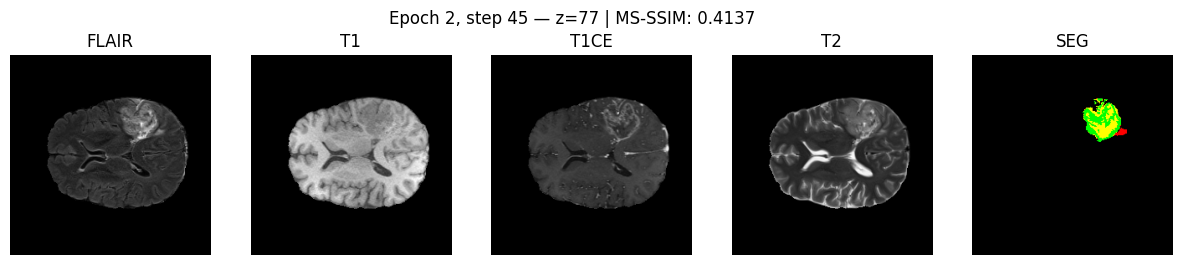

Epoch 2/30:  98%|█████████▊| 90/92 [03:12<00:04,  2.36s/it, loss=0.4966, ms-ssim=0.3712]

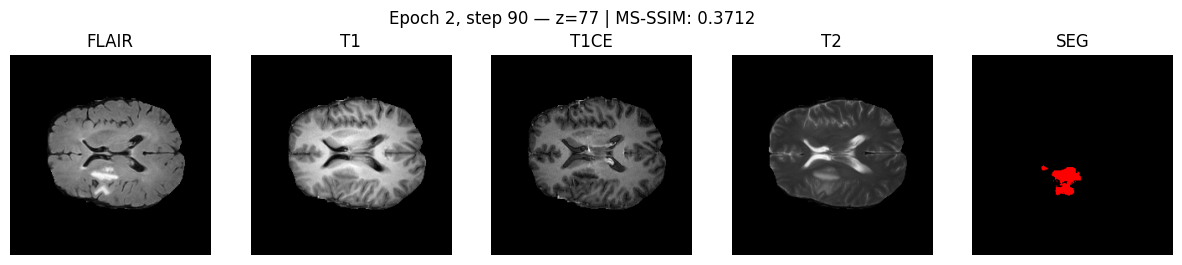

Epoch 2/30: 100%|██████████| 92/92 [03:17<00:00,  2.15s/it, loss=0.5304, ms-ssim=0.4412]


Epoch 02/30  avg loss = 0.60372  avg MS-SSIM = 0.4233


Epoch 3/30:  49%|████▉     | 45/92 [01:28<01:57,  2.50s/it, loss=0.4682, ms-ssim=0.4923]

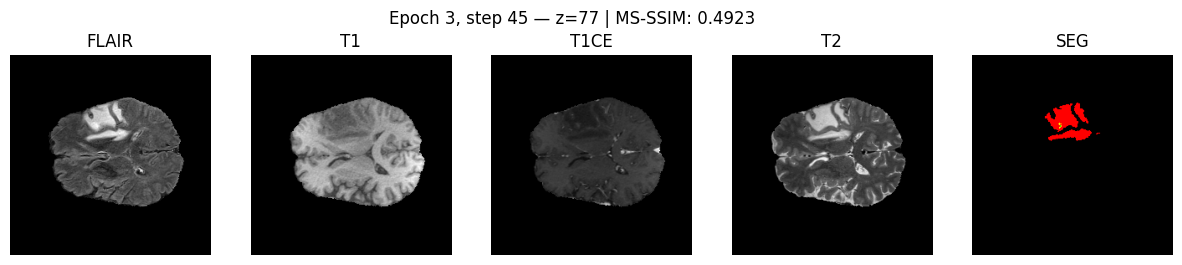

Epoch 3/30:  98%|█████████▊| 90/92 [03:14<00:06,  3.16s/it, loss=0.4130, ms-ssim=0.4709]

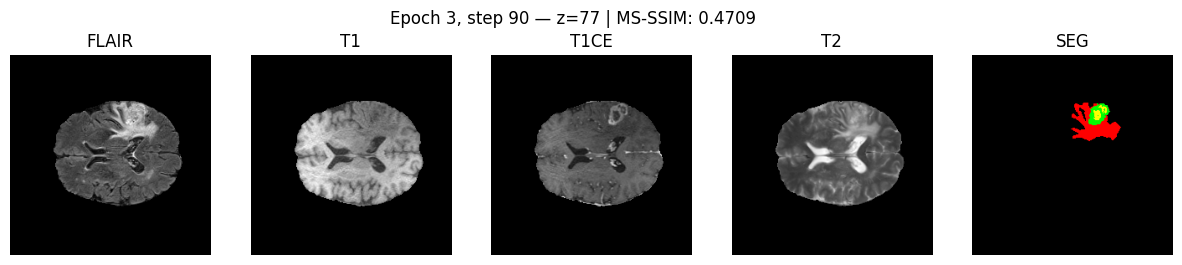

Epoch 3/30: 100%|██████████| 92/92 [03:15<00:00,  2.12s/it, loss=0.3686, ms-ssim=0.4169]


Epoch 03/30  avg loss = 0.44987  avg MS-SSIM = 0.4618


Epoch 4/30:  49%|████▉     | 45/92 [01:12<01:34,  2.01s/it, loss=0.3267, ms-ssim=0.4949]

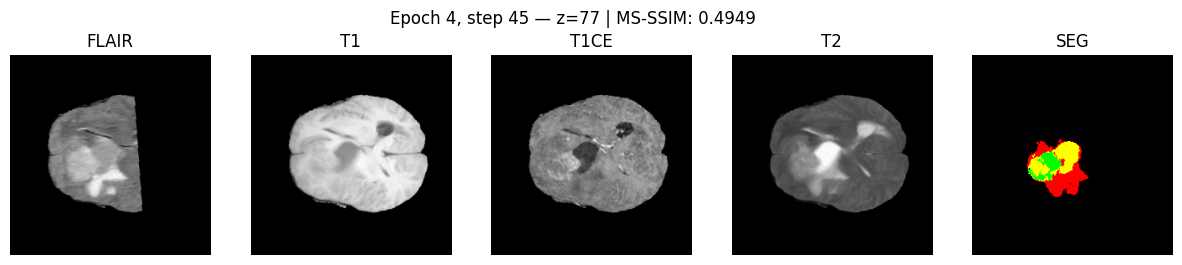

Epoch 4/30:  98%|█████████▊| 90/92 [02:57<00:04,  2.06s/it, loss=0.2946, ms-ssim=0.4560]

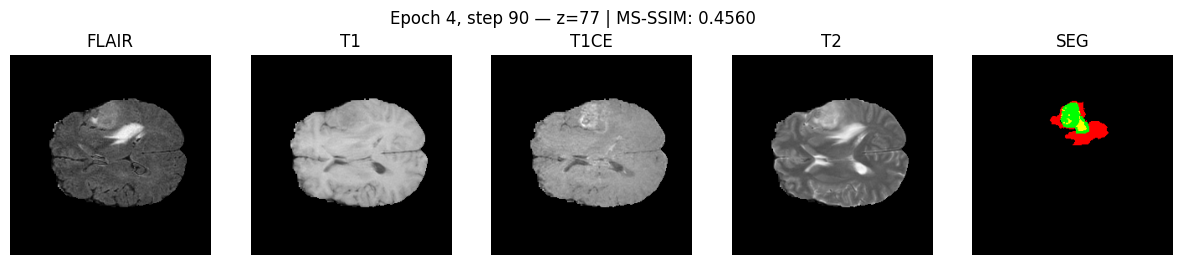

Epoch 4/30: 100%|██████████| 92/92 [03:01<00:00,  1.97s/it, loss=0.3134, ms-ssim=0.4725]


Epoch 04/30  avg loss = 0.34915  avg MS-SSIM = 0.4970


Epoch 5/30:  49%|████▉     | 45/92 [01:27<02:24,  3.08s/it, loss=0.2953, ms-ssim=0.5224]

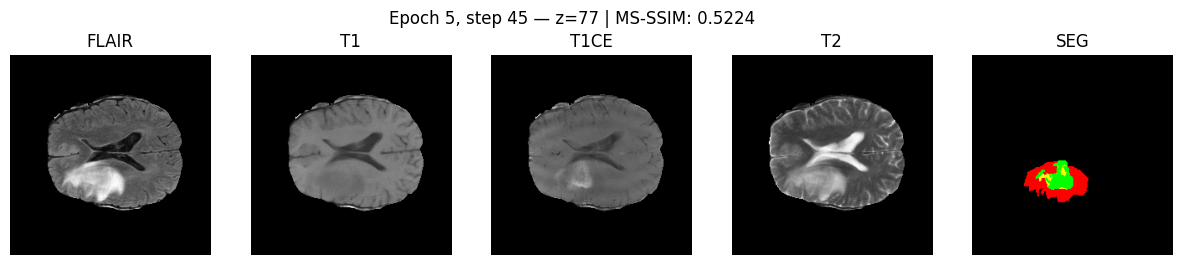

Epoch 5/30:  98%|█████████▊| 90/92 [03:08<00:03,  1.98s/it, loss=0.3012, ms-ssim=0.5526]

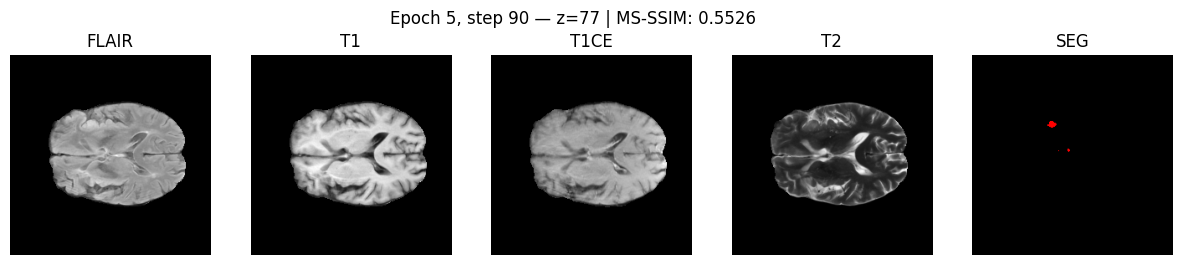

Epoch 5/30: 100%|██████████| 92/92 [03:13<00:00,  2.10s/it, loss=0.3009, ms-ssim=0.5140]


Epoch 05/30  avg loss = 0.30187  avg MS-SSIM = 0.5232


Epoch 6/30:  49%|████▉     | 45/92 [01:27<01:36,  2.06s/it, loss=0.3374, ms-ssim=0.4673]

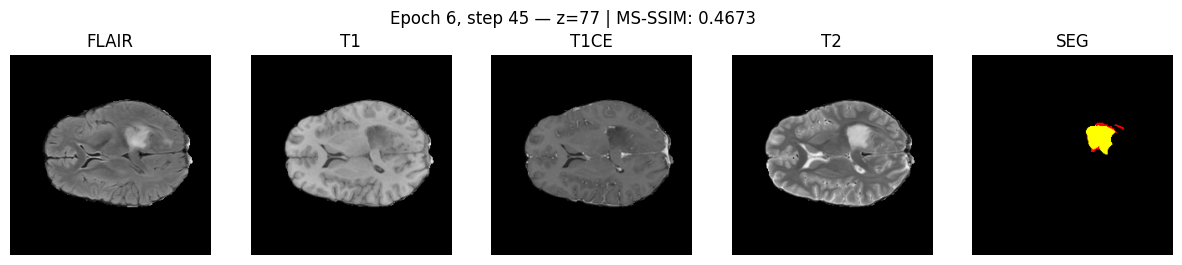

Epoch 6/30:  98%|█████████▊| 90/92 [03:11<00:05,  2.89s/it, loss=0.3711, ms-ssim=0.5326]

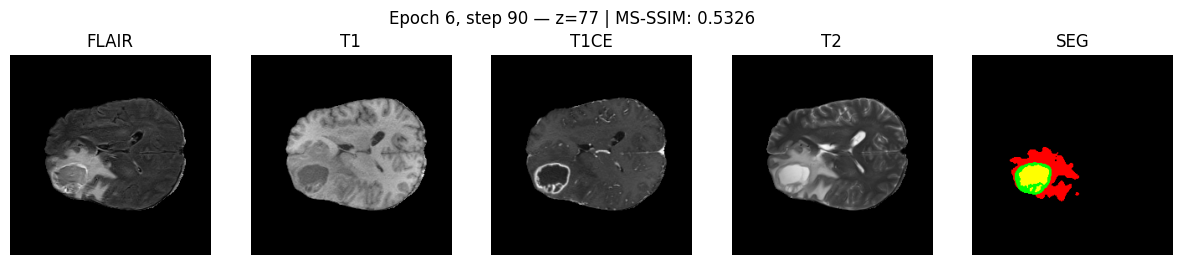

Epoch 6/30: 100%|██████████| 92/92 [03:13<00:00,  2.10s/it, loss=0.3642, ms-ssim=0.5424]


Epoch 06/30  avg loss = 0.34038  avg MS-SSIM = 0.5179


Epoch 7/30:  49%|████▉     | 45/92 [01:21<01:26,  1.84s/it, loss=0.3053, ms-ssim=0.4741]

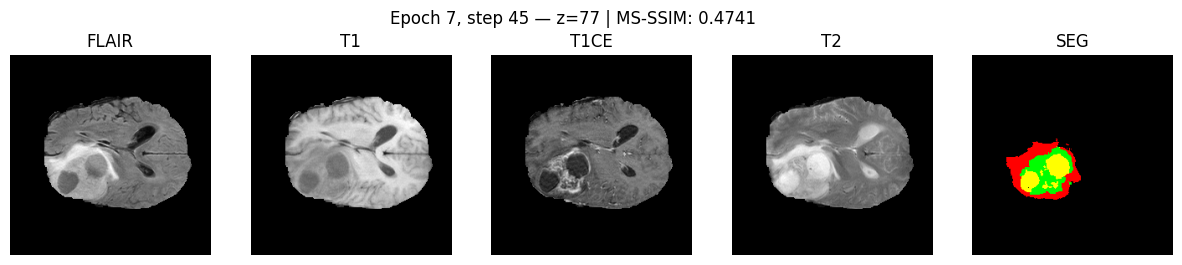

Epoch 7/30:  98%|█████████▊| 90/92 [03:11<00:06,  3.14s/it, loss=0.3028, ms-ssim=0.5318]

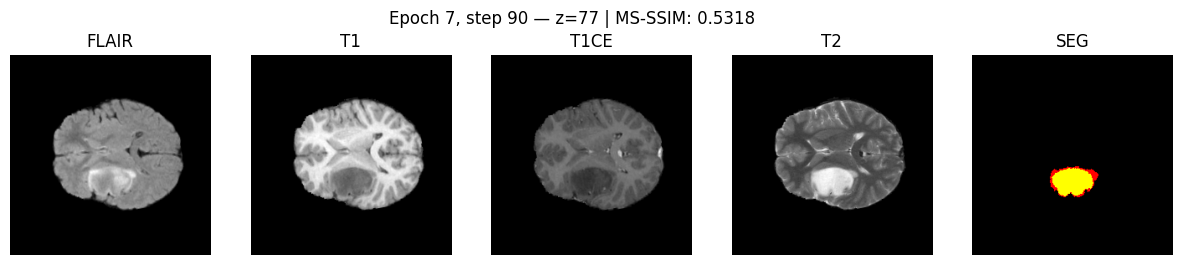

Epoch 7/30: 100%|██████████| 92/92 [03:13<00:00,  2.10s/it, loss=0.3262, ms-ssim=0.5772]


Epoch 07/30  avg loss = 0.32717  avg MS-SSIM = 0.5077


Epoch 8/30:  49%|████▉     | 45/92 [01:27<01:40,  2.14s/it, loss=0.2813, ms-ssim=0.5332]

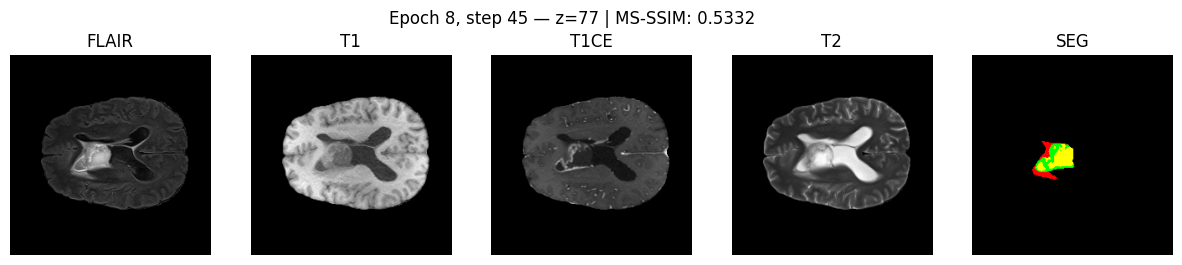

Epoch 8/30:  98%|█████████▊| 90/92 [03:15<00:05,  2.56s/it, loss=0.3032, ms-ssim=0.5982]

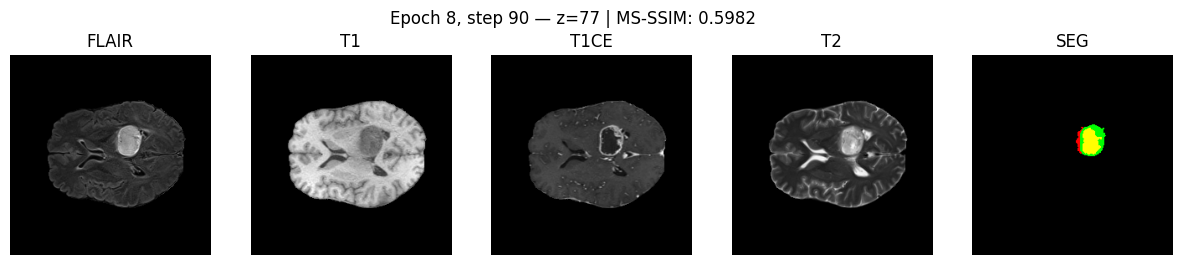

Epoch 8/30: 100%|██████████| 92/92 [03:18<00:00,  2.16s/it, loss=0.2486, ms-ssim=0.5623]


Epoch 08/30  avg loss = 0.28286  avg MS-SSIM = 0.5361


Epoch 9/30:  49%|████▉     | 45/92 [01:28<01:59,  2.54s/it, loss=0.2607, ms-ssim=0.5275]

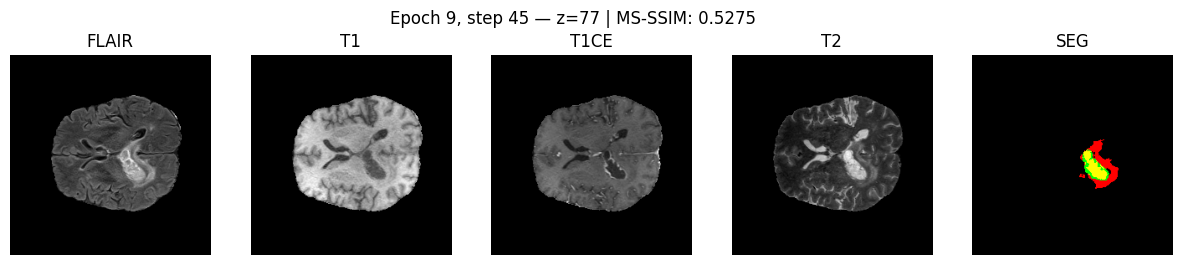

Epoch 9/30:  98%|█████████▊| 90/92 [03:10<00:04,  2.25s/it, loss=0.2592, ms-ssim=0.5811]

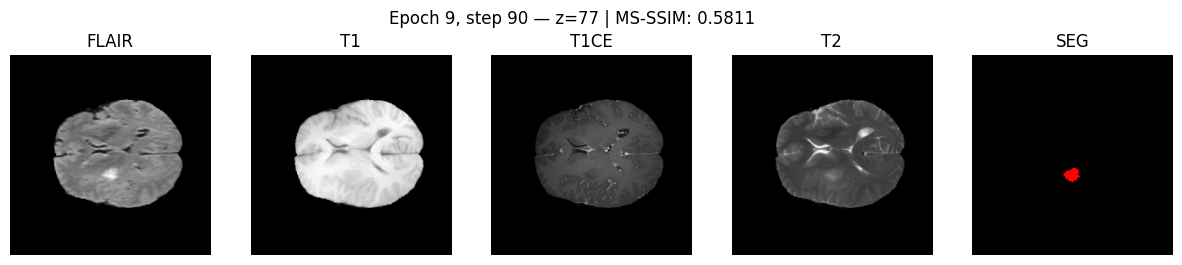

Epoch 9/30: 100%|██████████| 92/92 [03:16<00:00,  2.14s/it, loss=0.3116, ms-ssim=0.6089]


Epoch 09/30  avg loss = 0.26128  avg MS-SSIM = 0.5517


Epoch 10/30:  49%|████▉     | 45/92 [01:25<01:29,  1.90s/it, loss=0.2397, ms-ssim=0.5602]

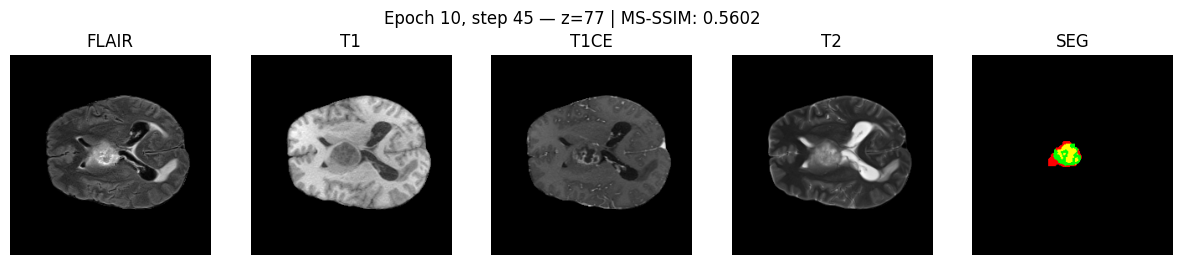

Epoch 10/30:  98%|█████████▊| 90/92 [03:04<00:03,  1.65s/it, loss=0.1968, ms-ssim=0.5140]

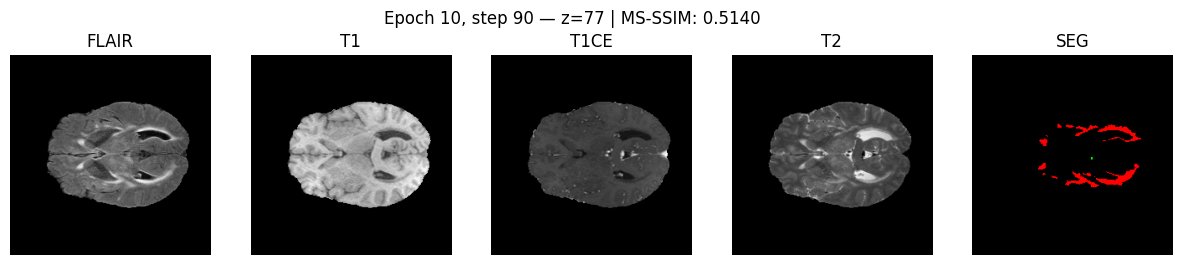

Epoch 10/30: 100%|██████████| 92/92 [03:10<00:00,  2.07s/it, loss=0.2301, ms-ssim=0.5449]


Epoch 10/30  avg loss = 0.24751  avg MS-SSIM = 0.5650


Epoch 11/30:  49%|████▉     | 45/92 [01:17<01:45,  2.24s/it, loss=0.2736, ms-ssim=0.6046]

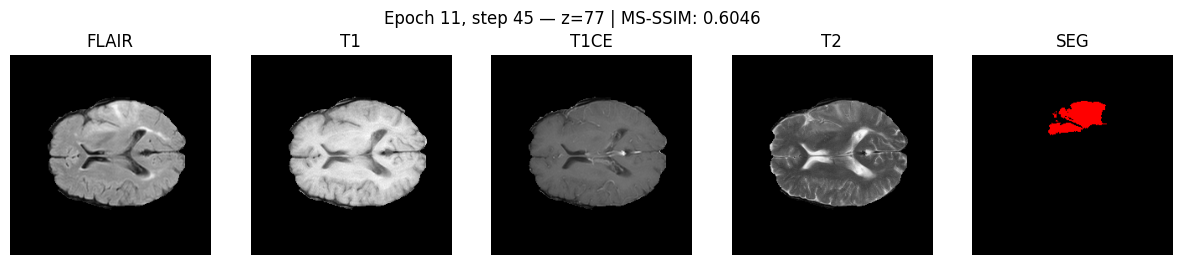

Epoch 11/30:  98%|█████████▊| 90/92 [03:02<00:05,  2.91s/it, loss=0.2506, ms-ssim=0.5592]

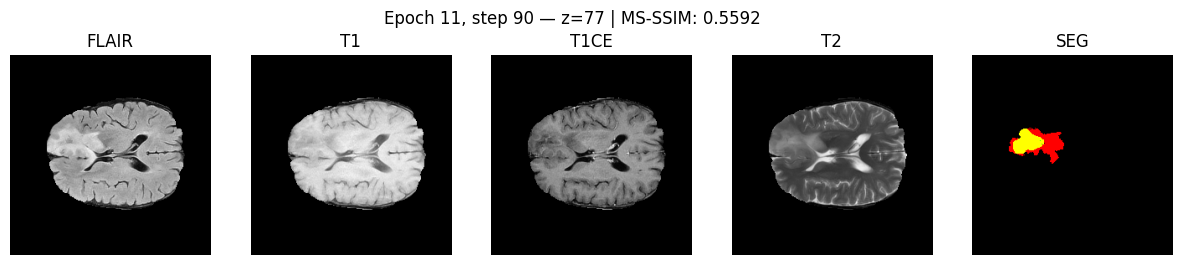

Epoch 11/30: 100%|██████████| 92/92 [03:05<00:00,  2.01s/it, loss=0.2103, ms-ssim=0.5419]


Epoch 11/30  avg loss = 0.24681  avg MS-SSIM = 0.5826


Epoch 12/30:  49%|████▉     | 45/92 [01:22<01:44,  2.23s/it, loss=0.2240, ms-ssim=0.5728]

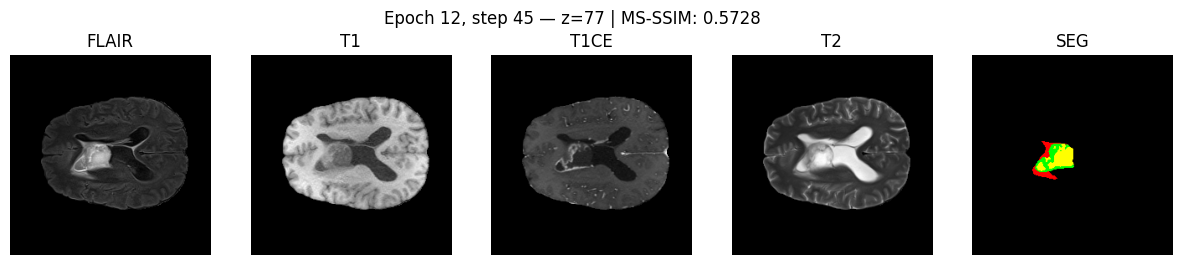

Epoch 12/30:  98%|█████████▊| 90/92 [03:04<00:04,  2.34s/it, loss=0.2008, ms-ssim=0.5313]

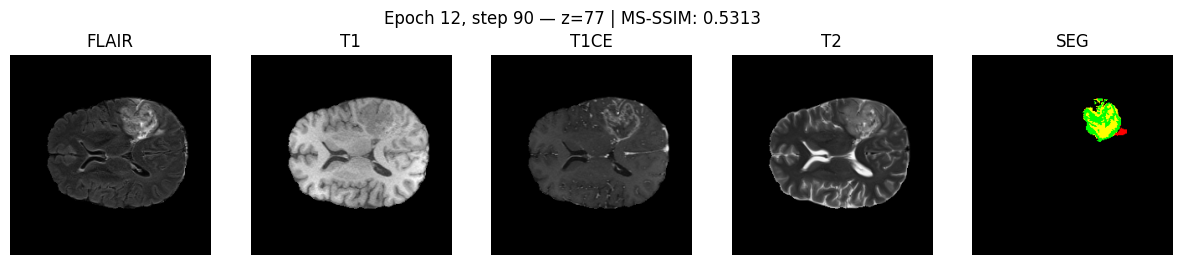

Epoch 12/30: 100%|██████████| 92/92 [03:10<00:00,  2.08s/it, loss=0.2196, ms-ssim=0.5827]


Epoch 12/30  avg loss = 0.23348  avg MS-SSIM = 0.5852


Epoch 13/30:  49%|████▉     | 45/92 [01:23<02:00,  2.56s/it, loss=0.2455, ms-ssim=0.6029]

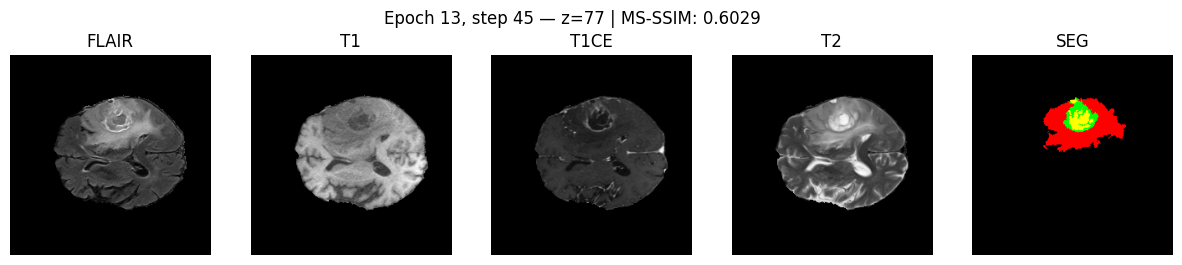

Epoch 13/30:  98%|█████████▊| 90/92 [03:09<00:04,  2.32s/it, loss=0.2641, ms-ssim=0.5865]

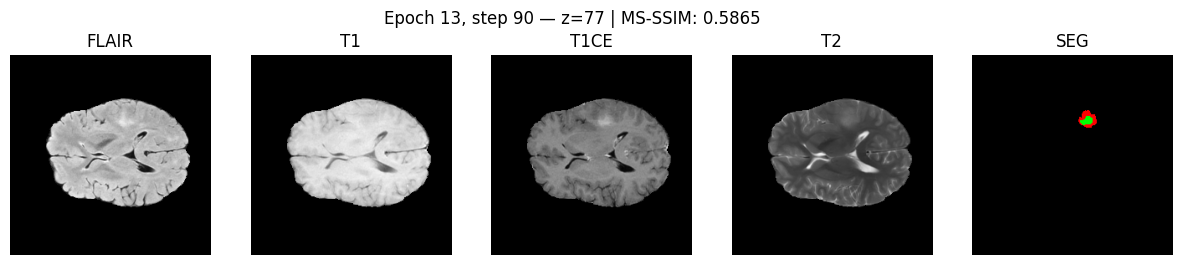

Epoch 13/30: 100%|██████████| 92/92 [03:13<00:00,  2.11s/it, loss=0.3073, ms-ssim=0.6414]


Epoch 13/30  avg loss = 0.24414  avg MS-SSIM = 0.5958


Epoch 14/30:  49%|████▉     | 45/92 [01:24<01:21,  1.73s/it, loss=0.3137, ms-ssim=0.5348]<ipython-input-43-98fef1a0dc25>:72: RuntimeWarning: divide by zero encountered in divide
  norm_vol = (vol - mn) / (mx - mn) * 2 - 1
<ipython-input-43-98fef1a0dc25>:72: RuntimeWarning: invalid value encountered in divide
  norm_vol = (vol - mn) / (mx - mn) * 2 - 1


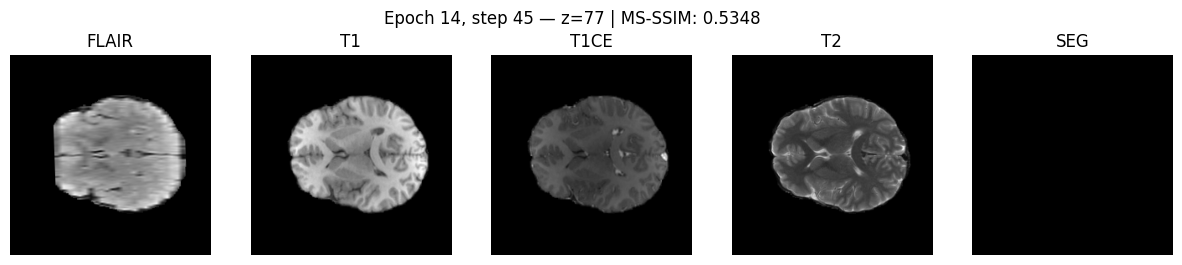

Epoch 14/30:  98%|█████████▊| 90/92 [03:13<00:04,  2.44s/it, loss=0.3268, ms-ssim=0.5944]

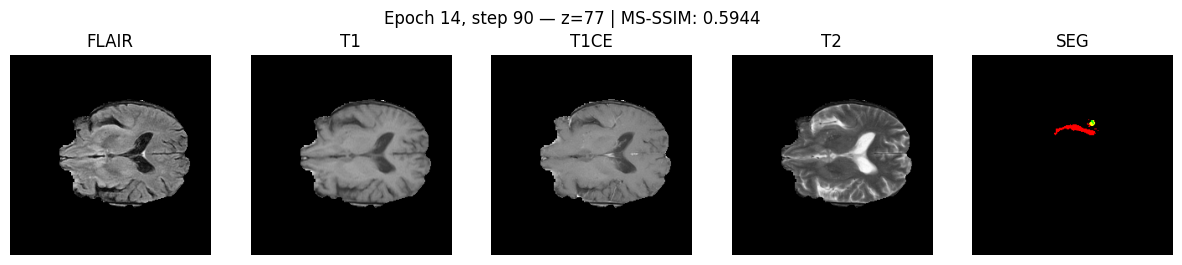

Epoch 14/30: 100%|██████████| 92/92 [03:18<00:00,  2.16s/it, loss=0.2887, ms-ssim=0.5015]


Epoch 14/30  avg loss = 0.30009  avg MS-SSIM = 0.5521


Epoch 15/30:  49%|████▉     | 45/92 [01:25<02:02,  2.61s/it, loss=0.3357, ms-ssim=0.5377]

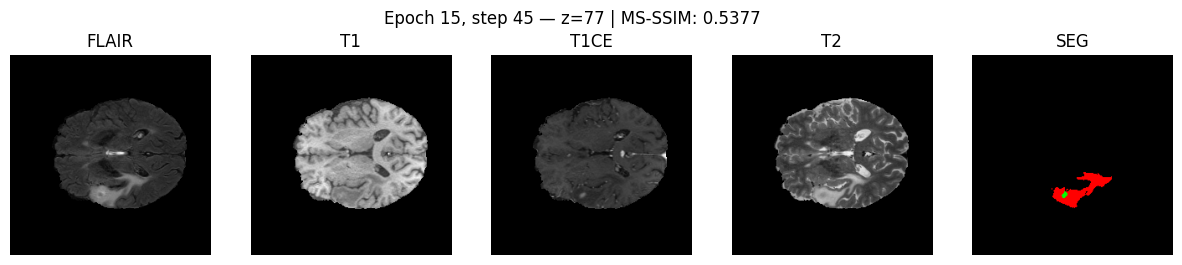

Epoch 15/30:  98%|█████████▊| 90/92 [03:34<00:03,  1.67s/it, loss=0.2245, ms-ssim=0.5270]

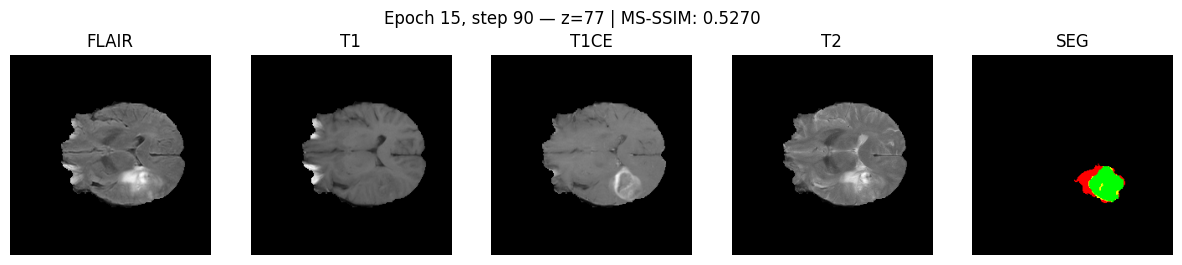

Epoch 15/30: 100%|██████████| 92/92 [03:38<00:00,  2.38s/it, loss=0.3158, ms-ssim=0.5749]


Epoch 15/30  avg loss = 0.33216  avg MS-SSIM = 0.5283


Epoch 16/30:  49%|████▉     | 45/92 [01:19<01:36,  2.06s/it, loss=0.2193, ms-ssim=0.6113]

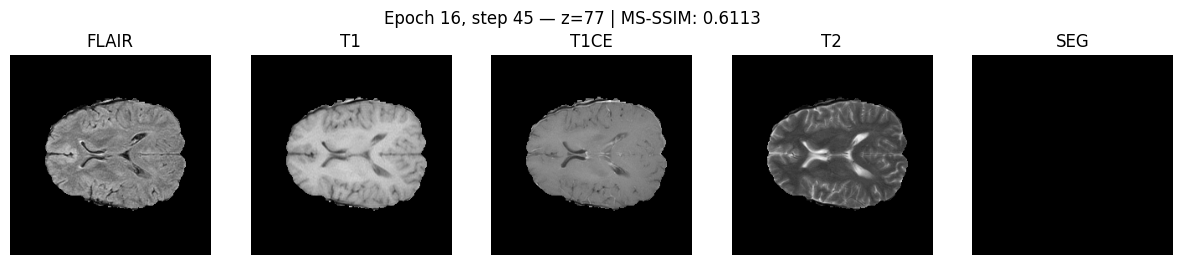

Epoch 16/30:  98%|█████████▊| 90/92 [03:22<00:11,  5.82s/it, loss=0.2301, ms-ssim=0.5005]

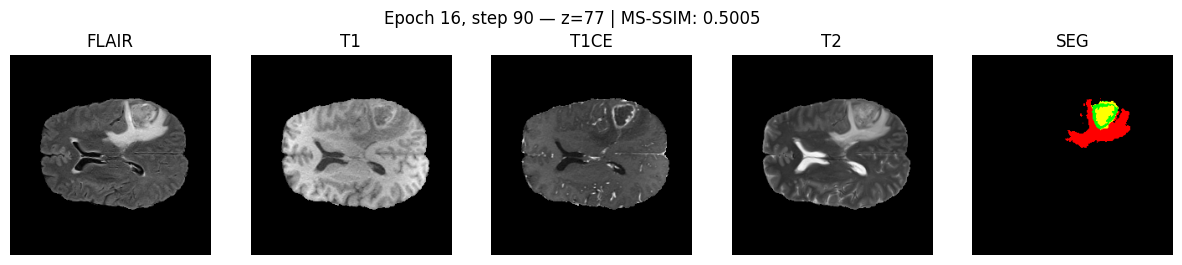

Epoch 16/30: 100%|██████████| 92/92 [03:23<00:00,  2.21s/it, loss=0.2842, ms-ssim=0.6067]


Epoch 16/30  avg loss = 0.25305  avg MS-SSIM = 0.5824


Epoch 17/30:  49%|████▉     | 45/92 [01:25<01:41,  2.16s/it, loss=0.1973, ms-ssim=0.5462]

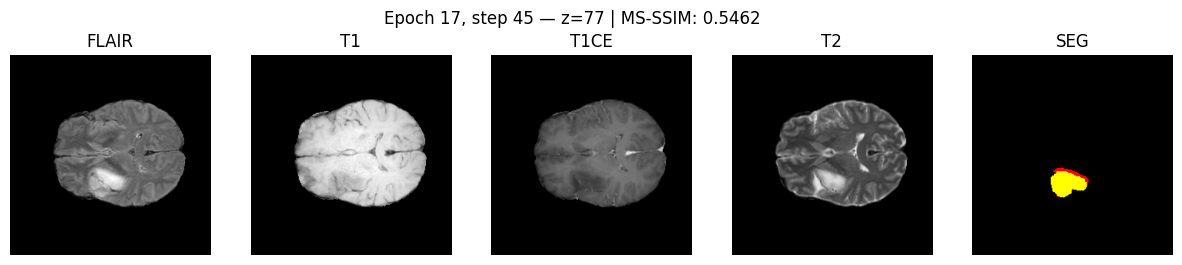

Epoch 17/30:  98%|█████████▊| 90/92 [03:08<00:05,  2.61s/it, loss=0.2462, ms-ssim=0.6455]

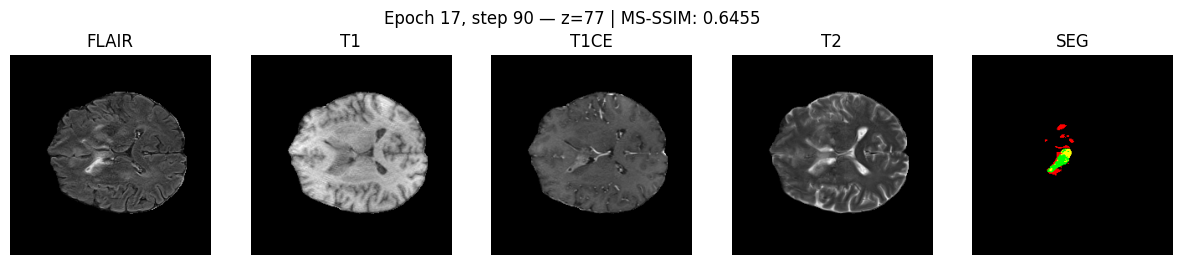

Epoch 17/30: 100%|██████████| 92/92 [03:09<00:00,  2.06s/it, loss=0.2279, ms-ssim=0.6326]


Epoch 17/30  avg loss = 0.23120  avg MS-SSIM = 0.5979


Epoch 18/30:  49%|████▉     | 45/92 [01:26<02:06,  2.70s/it, loss=0.2222, ms-ssim=0.5758]

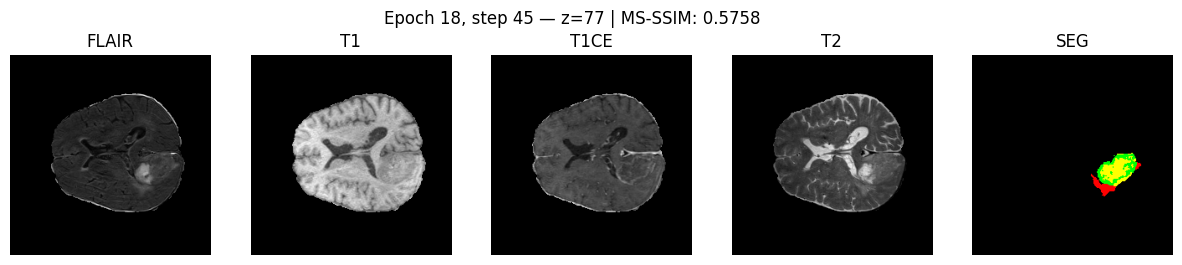

Epoch 18/30:  98%|█████████▊| 90/92 [03:05<00:03,  1.90s/it, loss=0.1610, ms-ssim=0.5224]

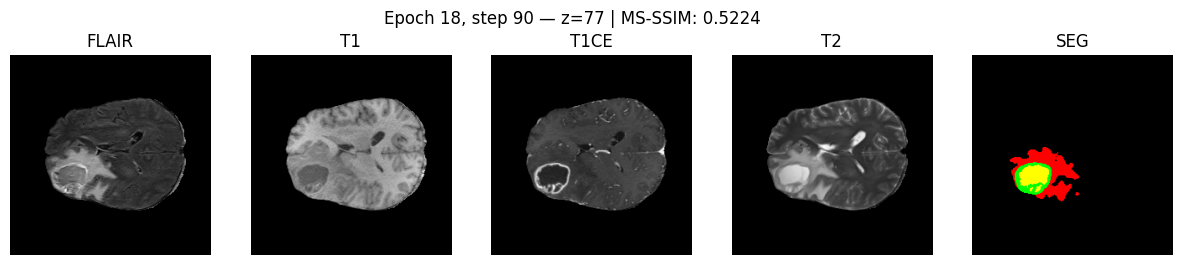

Epoch 18/30: 100%|██████████| 92/92 [03:09<00:00,  2.06s/it, loss=0.1862, ms-ssim=0.5413]


Epoch 18/30  avg loss = 0.21696  avg MS-SSIM = 0.6021


Epoch 19/30:  49%|████▉     | 45/92 [01:31<02:17,  2.92s/it, loss=0.2035, ms-ssim=0.5914]

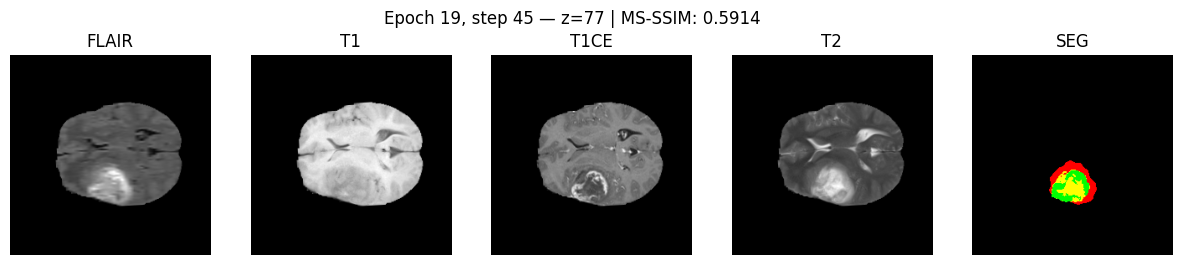

Epoch 19/30:  98%|█████████▊| 90/92 [03:13<00:04,  2.34s/it, loss=0.3248, ms-ssim=0.7459]

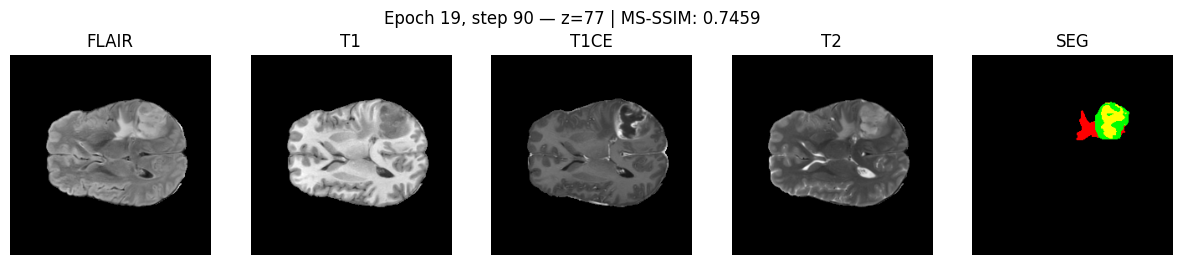

Epoch 19/30: 100%|██████████| 92/92 [03:14<00:00,  2.12s/it, loss=0.2210, ms-ssim=0.6903]


Epoch 19/30  avg loss = 0.21929  avg MS-SSIM = 0.6148


Epoch 20/30:  49%|████▉     | 45/92 [01:25<01:30,  1.92s/it, loss=0.2319, ms-ssim=0.6282]

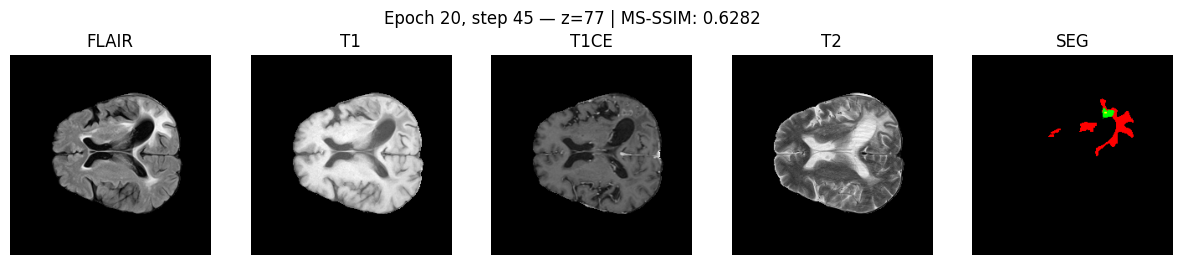

Epoch 20/30:  98%|█████████▊| 90/92 [03:10<00:04,  2.25s/it, loss=0.1755, ms-ssim=0.5870]

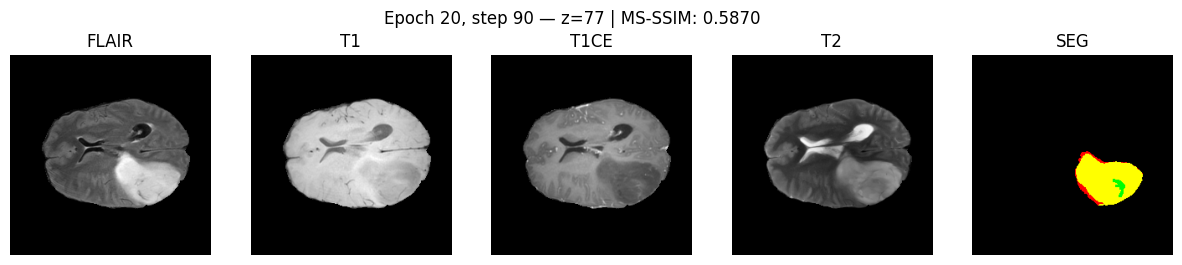

Epoch 20/30: 100%|██████████| 92/92 [03:12<00:00,  2.09s/it, loss=0.1978, ms-ssim=0.5750]


Epoch 20/30  avg loss = 0.21288  avg MS-SSIM = 0.6220


Epoch 21/30:  49%|████▉     | 45/92 [01:27<01:50,  2.35s/it, loss=0.2089, ms-ssim=0.5733]

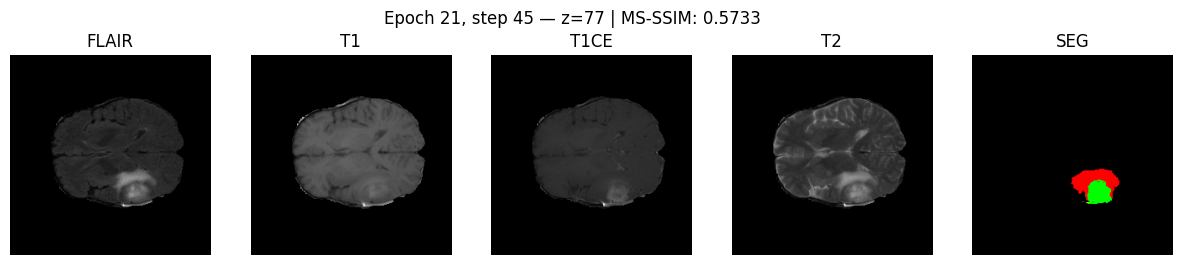

Epoch 21/30:  98%|█████████▊| 90/92 [03:08<00:05,  2.59s/it, loss=0.2344, ms-ssim=0.5356]

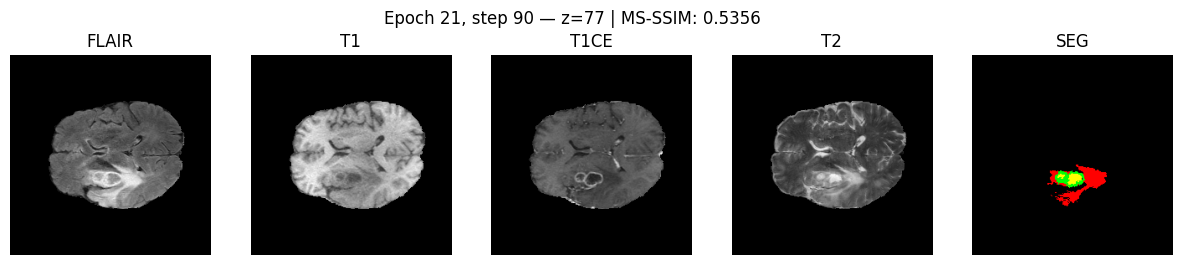

Epoch 21/30: 100%|██████████| 92/92 [03:10<00:00,  2.07s/it, loss=0.2005, ms-ssim=0.5910]


Epoch 21/30  avg loss = 0.22687  avg MS-SSIM = 0.6023


Epoch 22/30:  49%|████▉     | 45/92 [01:28<02:02,  2.61s/it, loss=0.3273, ms-ssim=0.5445]

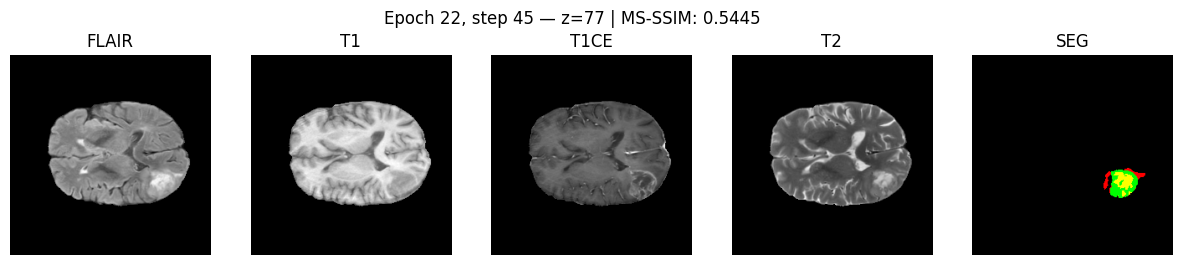

Epoch 22/30:  98%|█████████▊| 90/92 [03:12<00:05,  2.81s/it, loss=0.2783, ms-ssim=0.6934]

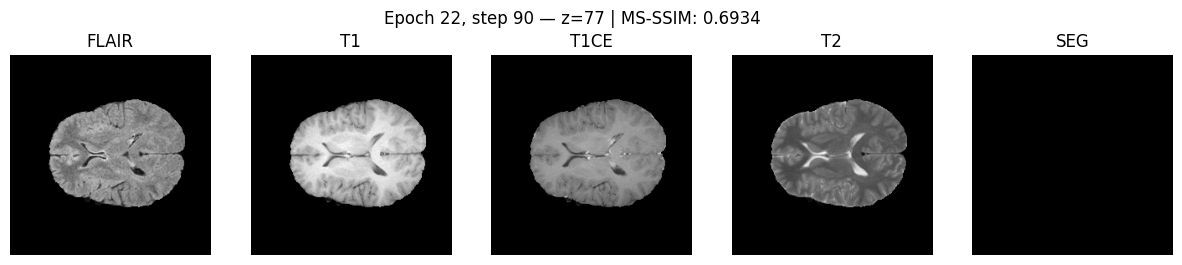

Epoch 22/30: 100%|██████████| 92/92 [03:14<00:00,  2.11s/it, loss=0.2415, ms-ssim=0.6562]


Epoch 22/30  avg loss = 0.24024  avg MS-SSIM = 0.5842


Epoch 23/30:  49%|████▉     | 45/92 [01:22<02:07,  2.72s/it, loss=0.2132, ms-ssim=0.5596]

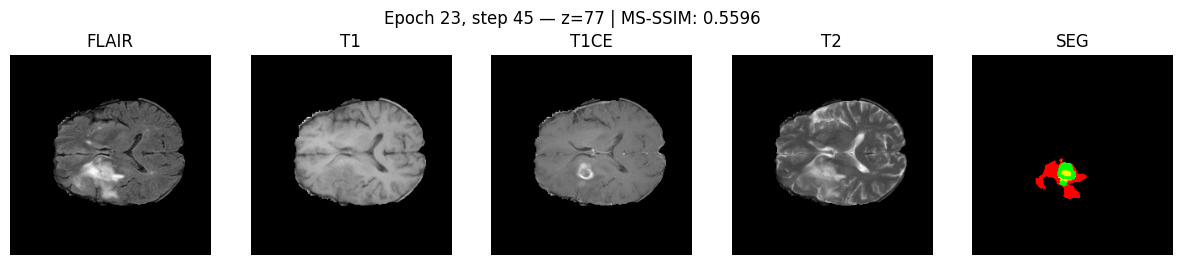

Epoch 23/30:  98%|█████████▊| 90/92 [03:05<00:05,  2.60s/it, loss=0.1906, ms-ssim=0.6254]

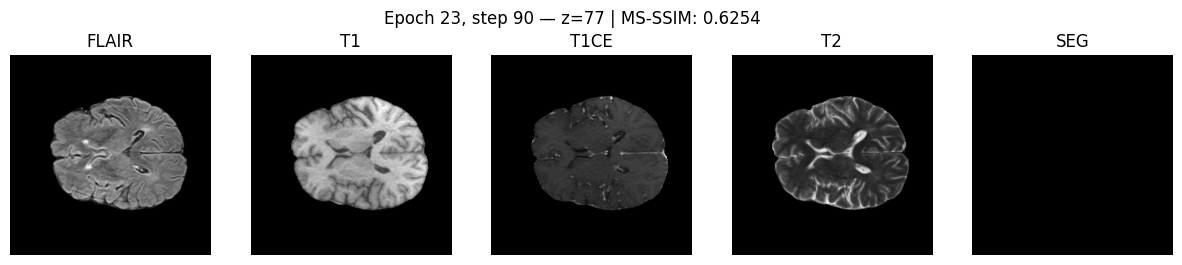

Epoch 23/30: 100%|██████████| 92/92 [03:09<00:00,  2.06s/it, loss=0.1483, ms-ssim=0.5032]


Epoch 23/30  avg loss = 0.21345  avg MS-SSIM = 0.6148


Epoch 24/30:  49%|████▉     | 45/92 [01:21<01:26,  1.84s/it, loss=0.2020, ms-ssim=0.6016]

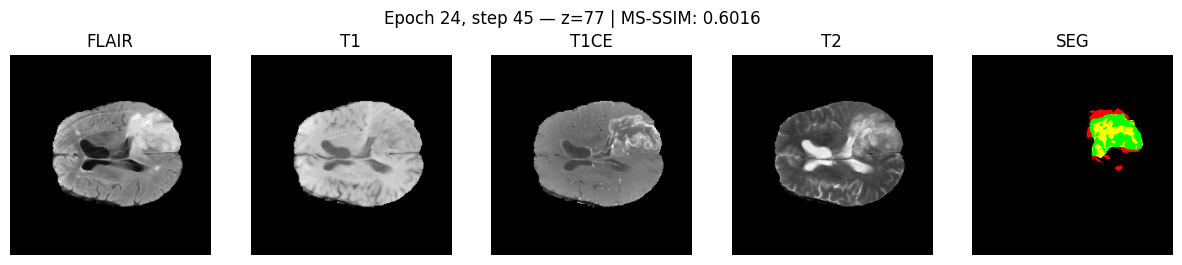

Epoch 24/30:  98%|█████████▊| 90/92 [03:06<00:05,  2.67s/it, loss=0.1859, ms-ssim=0.5710]

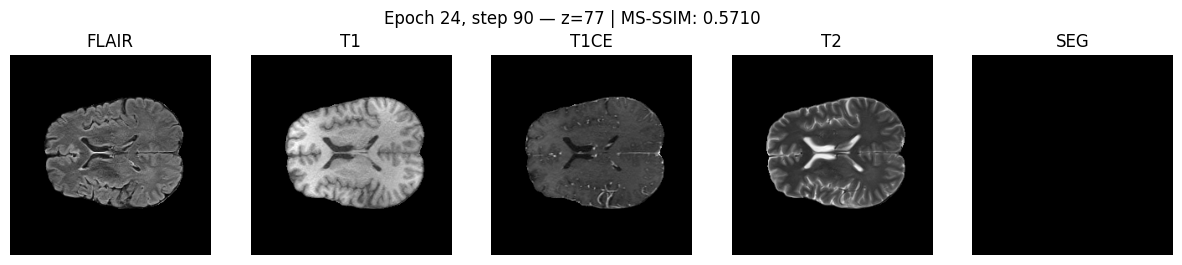

Epoch 24/30: 100%|██████████| 92/92 [03:07<00:00,  2.04s/it, loss=0.1696, ms-ssim=0.6575]


Epoch 24/30  avg loss = 0.20175  avg MS-SSIM = 0.6232


Epoch 25/30:  49%|████▉     | 45/92 [01:22<02:04,  2.64s/it, loss=0.1540, ms-ssim=0.5613]

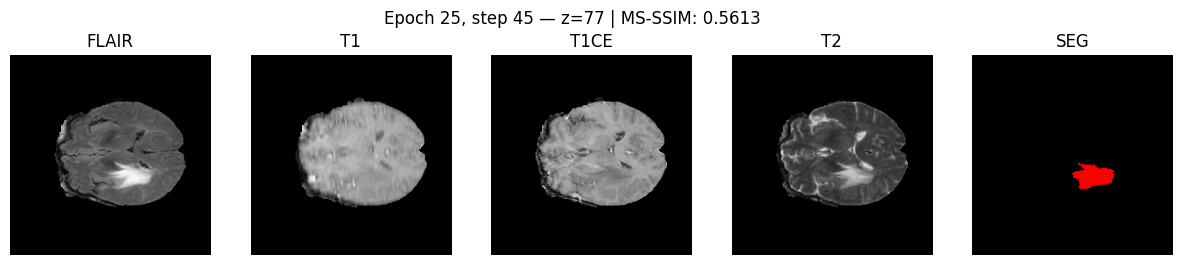

Epoch 25/30:  98%|█████████▊| 90/92 [02:57<00:04,  2.06s/it, loss=0.1710, ms-ssim=0.5962]

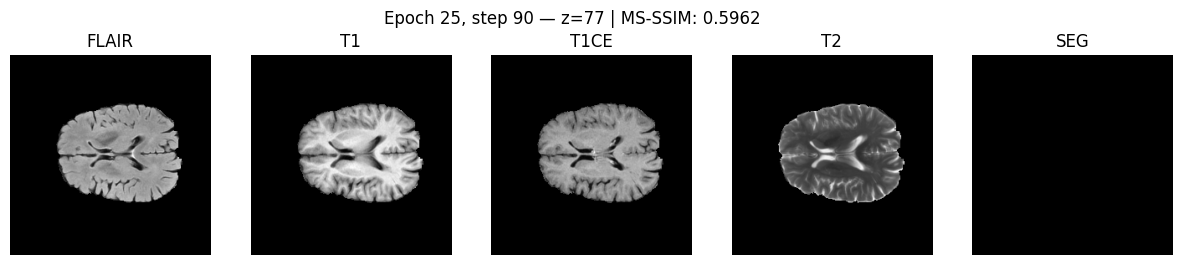

Epoch 25/30: 100%|██████████| 92/92 [03:02<00:00,  1.98s/it, loss=0.1999, ms-ssim=0.6249]


Epoch 25/30  avg loss = 0.20505  avg MS-SSIM = 0.6180


Epoch 26/30:  49%|████▉     | 45/92 [01:18<01:37,  2.06s/it, loss=0.1712, ms-ssim=0.6149]

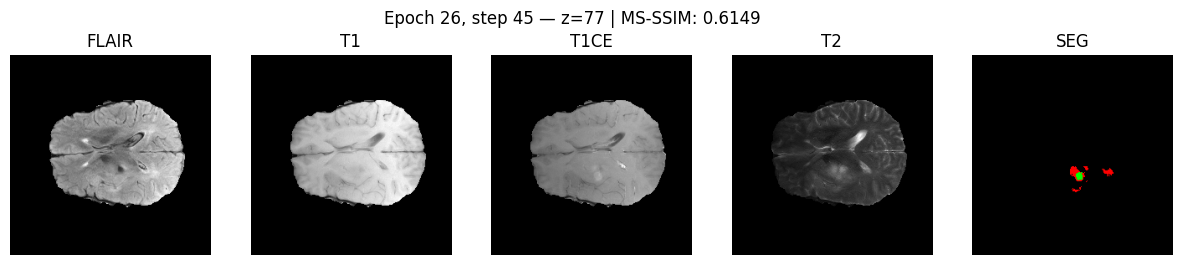

Epoch 26/30:  98%|█████████▊| 90/92 [03:00<00:04,  2.13s/it, loss=0.2008, ms-ssim=0.6132]

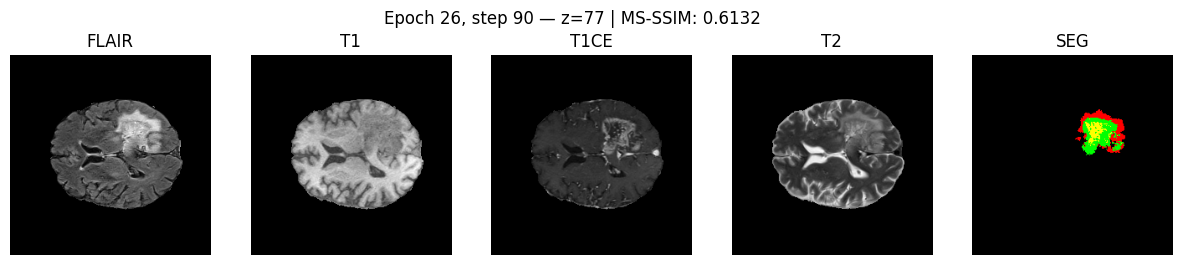

Epoch 26/30: 100%|██████████| 92/92 [03:04<00:00,  2.01s/it, loss=0.1898, ms-ssim=0.6286]


Epoch 26/30  avg loss = 0.20119  avg MS-SSIM = 0.6212


Epoch 27/30:  49%|████▉     | 45/92 [01:15<01:35,  2.04s/it, loss=0.1507, ms-ssim=0.5105]

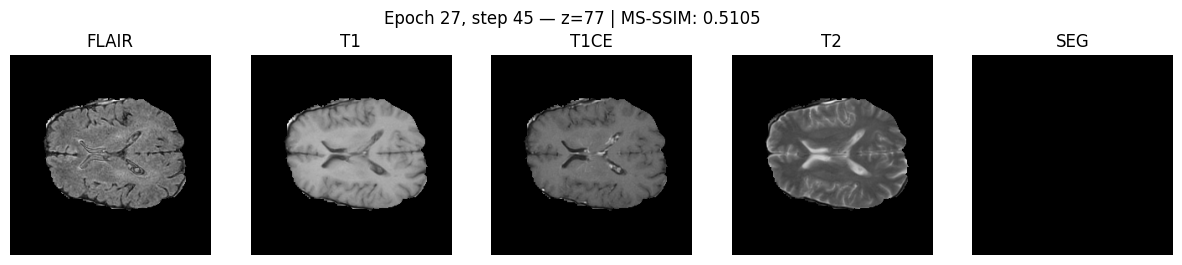

Epoch 27/30:  98%|█████████▊| 90/92 [03:01<00:05,  2.62s/it, loss=0.1795, ms-ssim=0.5902]

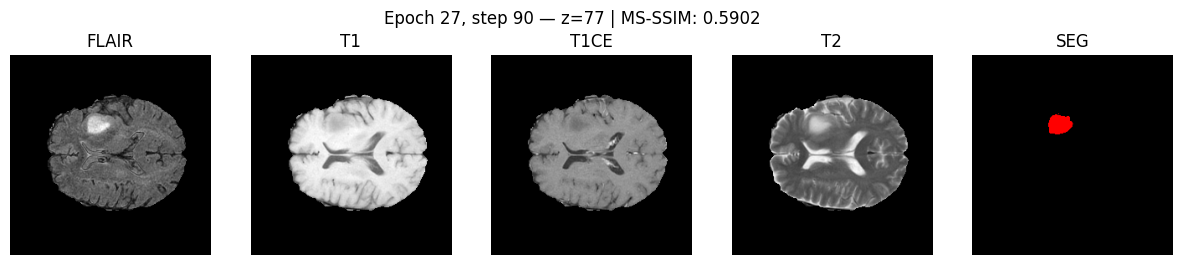

Epoch 27/30: 100%|██████████| 92/92 [03:03<00:00,  1.99s/it, loss=0.1969, ms-ssim=0.5362]


Epoch 27/30  avg loss = 0.19165  avg MS-SSIM = 0.6163


Epoch 28/30:  49%|████▉     | 45/92 [01:21<01:48,  2.31s/it, loss=0.1798, ms-ssim=0.6463]

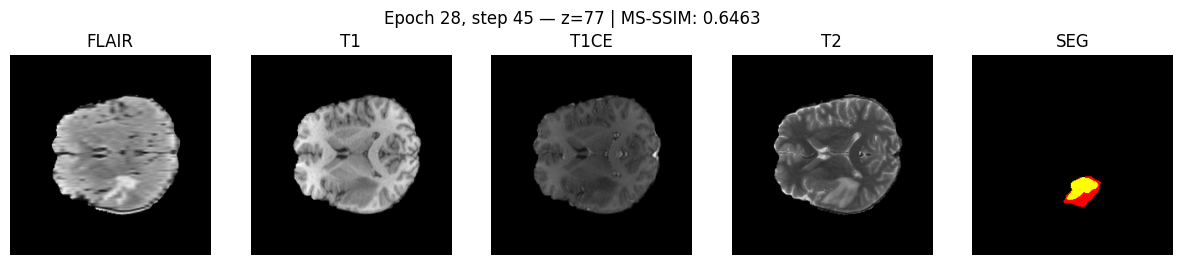

Epoch 28/30:  98%|█████████▊| 90/92 [03:02<00:03,  1.79s/it, loss=0.1943, ms-ssim=0.5611]

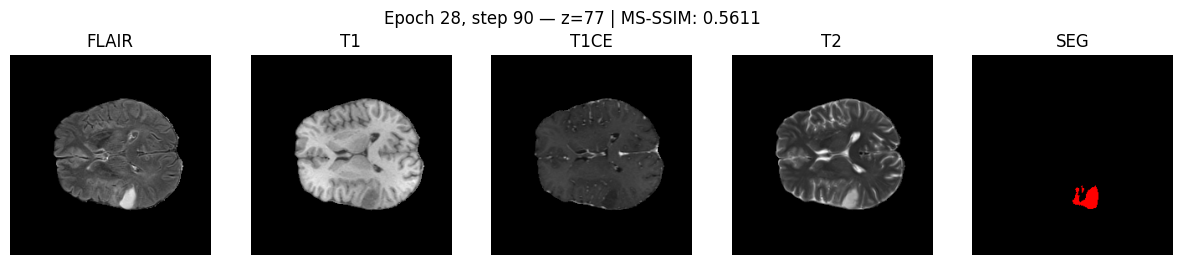

Epoch 28/30: 100%|██████████| 92/92 [03:07<00:00,  2.04s/it, loss=0.1860, ms-ssim=0.5958]


Epoch 28/30  avg loss = 0.19444  avg MS-SSIM = 0.6249


Epoch 29/30:  49%|████▉     | 45/92 [01:18<01:52,  2.39s/it, loss=0.1913, ms-ssim=0.6192]

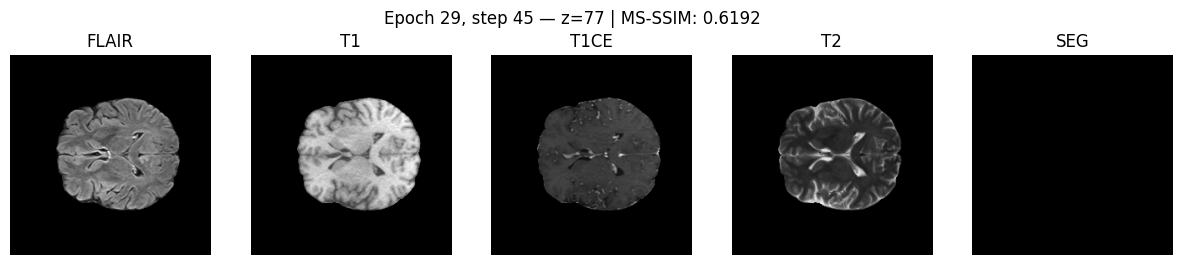

Epoch 29/30:  98%|█████████▊| 90/92 [02:57<00:04,  2.23s/it, loss=0.1808, ms-ssim=0.6129]

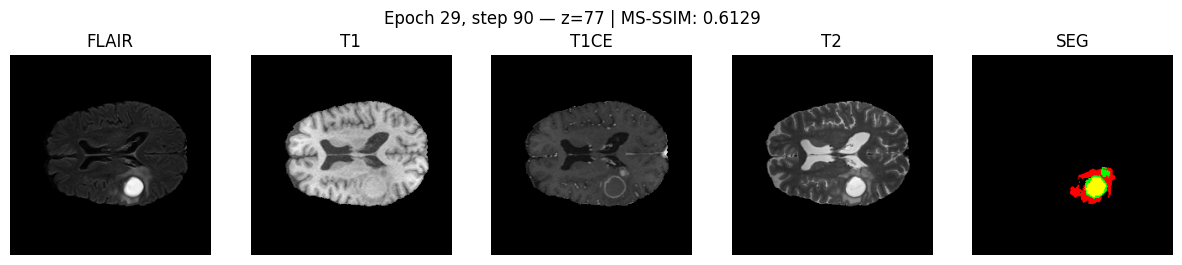

Epoch 29/30: 100%|██████████| 92/92 [02:59<00:00,  1.96s/it, loss=0.1907, ms-ssim=0.6368]


Epoch 29/30  avg loss = 0.19277  avg MS-SSIM = 0.6316


Epoch 30/30:  49%|████▉     | 45/92 [01:18<01:24,  1.80s/it, loss=0.2005, ms-ssim=0.6191]

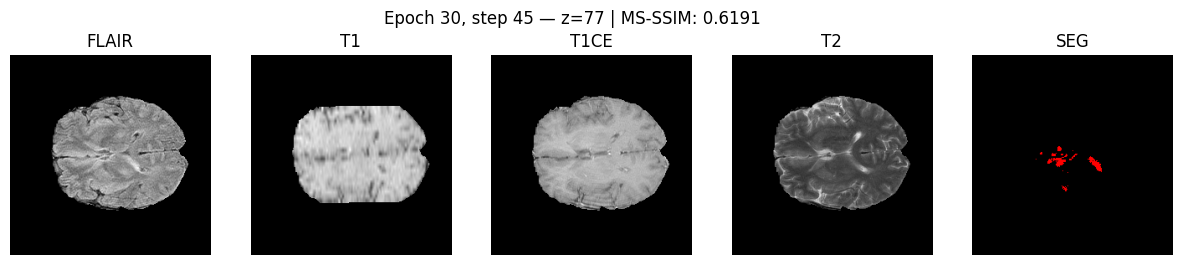

Epoch 30/30:  98%|█████████▊| 90/92 [02:57<00:02,  1.32s/it, loss=0.1730, ms-ssim=0.6370]

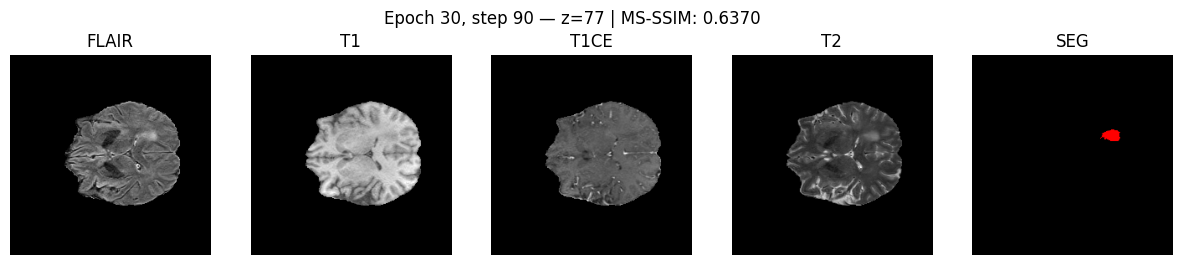

Epoch 30/30: 100%|██████████| 92/92 [03:03<00:00,  1.99s/it, loss=0.1595, ms-ssim=0.5792]


Epoch 30/30  avg loss = 0.19128  avg MS-SSIM = 0.6291
Picked file: /content/drive/MyDrive/brats_saved/flair/BraTS20_Training_344_synthetic_flair.nii
Shape is: (240, 240, 155)


In [ ]:
# NII save path
OUTPUT_ROOT = '/content/drive/MyDrive/brats_saved'
MODS = ['flair','t1','t1ce','t2','seg']
for m in MODS:
    os.makedirs(os.path.join(OUTPUT_ROOT, m), exist_ok=True)

# Colormap setup
label_colors = {
    0: (0.0, 0.0, 0.0),   # background → black
    1: (1.0, 1.0, 0.0),   # label 1 → yellow
    2: (1.0, 0.0, 0.0),   # label 2 → red
    4: (0.0, 1.0, 0.0),   # label 4 → green
}
classes = sorted(label_colors.keys())
cmap   = colors.ListedColormap([label_colors[c] for c in classes])
bounds = [c - 0.5 for c in classes] + [classes[-1] + 0.5]
norm   = colors.BoundaryNorm(bounds, cmap.N)

# Training loop with colored seg panels
for epoch in range(1, EPOCHS + 1):
    total_loss = tf.constant(0.0, tf.float32)
    total_ms   = tf.constant(0.0, tf.float32)
    steps      = tf.constant(0,   tf.int32)

    with tqdm(total=tf.data.experimental.cardinality(ds).numpy(),
              desc=f"Epoch {epoch}/{EPOCHS}") as pbar:

        for window_batch, path_batch in ds:
            # train_step now returns both MSE loss and mean MS-SSIM
            loss, ms_ssim = train_step(window_batch)
            total_loss += loss
            total_ms   += ms_ssim
            steps      += 1

            # update progress bar
            pbar.update(1)
            pbar.set_postfix({
                'loss':    f"{loss.numpy():.4f}",
                'ms-ssim': f"{ms_ssim.numpy():.4f}"
            })

            # every 45 steps, show & save modalities + report MS-SSIM
            if tf.equal(steps % 45, 0):
                fpath    = path_batch[0].numpy().decode('utf-8')
                subj_dir = os.path.dirname(fpath)
                flair    = nib.load(fpath).get_fdata().astype(np.float32)
                iz       = flair.shape[2] // 2

                fig, axes = plt.subplots(1, len(MODS), figsize=(15, 3))
                for ax, m in zip(axes, MODS):
                    # load the raw slice
                    mod_fn   = os.path.basename(fpath).replace('flair', m)
                    mod_path = os.path.join(subj_dir, mod_fn)
                    vol      = nib.load(mod_path).get_fdata()
                    sl       = vol[:, :, iz]
                    mn, mx   = sl.min(), sl.max()

                    # plot
                    if m == 'seg':
                        ax.imshow(sl.astype(int), cmap=cmap, norm=norm)
                    else:
                        sl_norm = (sl - mn) / (mx - mn) * 2 - 1
                        ax.imshow(sl_norm, cmap='gray')
                    ax.set_title(m.upper())
                    ax.axis('off')

                    # save the full volume slice-norm’d back to [-1,1]
                    norm_vol = (vol - mn) / (mx - mn) * 2 - 1
                    out_fn   = mod_fn.replace(
                                  '.nii',
                                  f'_ep{epoch:02d}_st{steps.numpy():03d}.nii'
                               )
                    out_dir  = os.path.join(OUTPUT_ROOT, m)
                    out_path = os.path.join(out_dir, out_fn)
                    nib.save(
                        nib.Nifti1Image(norm_vol.astype(np.float32),
                                        affine=nib.load(mod_path).affine),
                        out_path
                    )

                plt.suptitle(
                    f"Epoch {epoch}, step {steps.numpy()} — z={iz} | "
                    f"MS-SSIM: {ms_ssim.numpy():.4f}"
                )
                plt.show()

    # epoch averages
    avg_loss = total_loss / tf.cast(steps, tf.float32)
    avg_ms   = total_ms   / tf.cast(steps, tf.float32)
    print(
        f"Epoch {epoch:02d}/{EPOCHS}  "
        f"avg loss = {avg_loss:.5f}  "
        f"avg MS-SSIM = {avg_ms:.4f}"
    )


# Pick one saved .nii and show its shape:
all_flair = glob.glob(os.path.join(OUTPUT_ROOT, 'flair', '*.nii'))
sample    = all_flair[0]
nii       = nib.load(sample)
print("Picked file:", sample)
print("Shape is:", nii.get_fdata().shape)

